# Análisis exploratorio de datos (EDA)

## Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Configurar visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## Asignar nombres de columnas en el dataset

In [2]:
# Nombres de columnas
nombres = [
    "wkblk", "wknwy", "wkna8", "wkona", "wkspr", "wkxbq", "wkxcr", "wkxbp",
    "whxbp", "wxqsq", "cntxt", "dsopp", "dwipd", "hdchk", "katri", "mulch",
    "qxmsq", "r2ar8", "reskd", "reskr", "rimmx", "rkxwp", "rxmsq", "simpl",
    "skach", "skewr", "skrxp", "spcop", "stlmt", "thrsk", "bkcti", "bkna8",
    "bknck", "bkovl", "bkpos", "btoeg", "class"
]


## Análisis de la variable target "class"

In [3]:
# Cargar datos
datos = pd.read_csv("kr-vs-kp.data", header=None, names=nombres)

# Convertir a tipo 'category' (equivalente a factor en R)
for col in datos.columns:
    datos[col] = datos[col].astype('category')

# Inspección inicial
print("Dimensiones:", datos.shape)
print("\nTipos de datos:")
print(datos.dtypes)
print("\nPrimeras filas:")
print(datos.head())

print("Valores nulos por columna:")
print(datos.isnull().sum())
print("\nNo hay NAs en el dataset.")

Dimensiones: (3196, 37)

Tipos de datos:
wkblk    category
wknwy    category
wkna8    category
wkona    category
wkspr    category
wkxbq    category
wkxcr    category
wkxbp    category
whxbp    category
wxqsq    category
cntxt    category
dsopp    category
dwipd    category
hdchk    category
katri    category
mulch    category
qxmsq    category
r2ar8    category
reskd    category
reskr    category
rimmx    category
rkxwp    category
rxmsq    category
simpl    category
skach    category
skewr    category
skrxp    category
spcop    category
stlmt    category
thrsk    category
bkcti    category
bkna8    category
bknck    category
bkovl    category
bkpos    category
btoeg    category
class    category
dtype: object

Primeras filas:
  wkblk wknwy wkna8 wkona wkspr wkxbq wkxcr wkxbp whxbp wxqsq cntxt dsopp  \
0     f     f     f     f     f     f     f     f     f     f     f     f   
1     f     f     f     f     t     f     f     f     f     f     f     f   
2     f     f     f     f     t

Tabla de frecuencias de class:
   class  Frecuencia  Porcentaje      Etiqueta
0    won        1669        52.2  1669 (52.2%)
1  nowin        1527        47.8  1527 (47.8%)


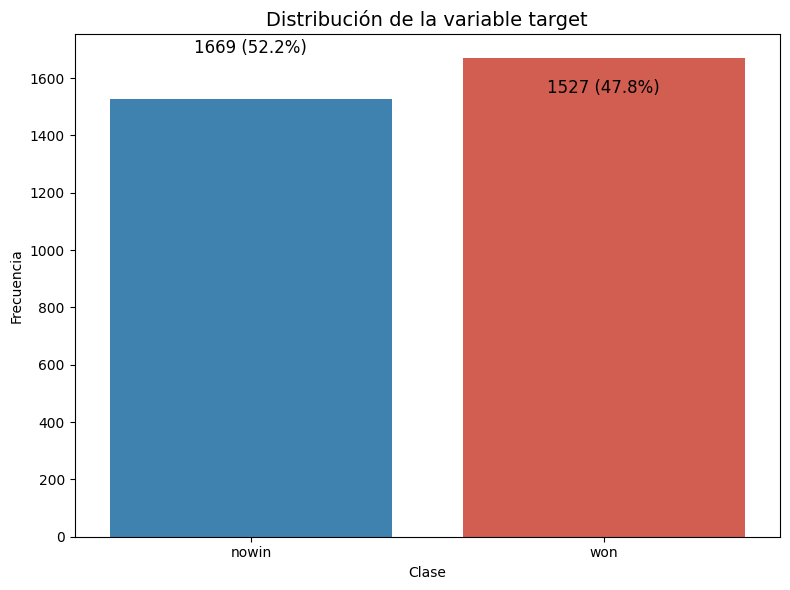

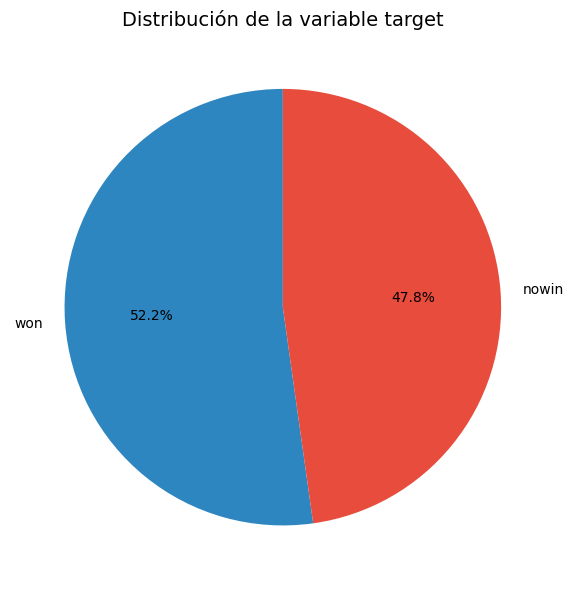

In [4]:
# Tabla de frecuencias
tabla_target = datos['class'].value_counts().reset_index()
tabla_target.columns = ['class', 'Frecuencia']
tabla_target['Porcentaje'] = round((tabla_target['Frecuencia'] / tabla_target['Frecuencia'].sum()) * 100, 1)
tabla_target['Etiqueta'] = tabla_target['Frecuencia'].astype(str) + " (" + tabla_target['Porcentaje'].astype(str) + "%)"

print("Tabla de frecuencias de class:")
print(tabla_target)

# Gráfico de barras 
plt.figure(figsize=(8, 6))
sns.barplot(data=tabla_target, x='class', y='Frecuencia', 
            palette=['#2E86C1', '#E74C3C'])
for i, row in tabla_target.iterrows():
    plt.text(i, row['Frecuencia'] + 20, row['Etiqueta'], ha='center', fontsize=12)
plt.title('Distribución de la variable target', fontsize=14)
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Gráfico de torta
plt.figure(figsize=(8, 6))
plt.pie(tabla_target['Frecuencia'], labels=tabla_target['class'], autopct='%1.1f%%', 
        colors=['#2E86C1', '#E74C3C'], startangle=90)
plt.title('Distribución de la variable target', fontsize=14)
plt.tight_layout()
plt.show()

En 1669 partidas, el 52.2%, resultó 'won', es decir que las blancas ganaron, y en 1527 partidas, el 47.8%, resultó 'nowin', es decir que el peón negro logró coronar o las negras consiguieron tablas; la diferencia entre ambas clases es de solo 4.4 puntos porcentuales, lo que indica que el dataset no tiene un sesgo significativo hacia ninguna clase.

## Análisis de las variables independientes

In [5]:
# Calcular frecuencias
vars_predictoras = [col for col in datos.columns if col != 'class']

frecuencias_list = []
for var in vars_predictoras:
    for valor in datos[var].unique():
        n = (datos[var] == valor).sum()
        pct = round((n / len(datos)) * 100, 1)
        frecuencias_list.append({'variable': var, 'valor': valor, 'n': n, 'porcentaje': pct})

frecuencias = pd.DataFrame(frecuencias_list)

# Variables con 2 niveles
binarias = frecuencias[frecuencias.groupby('variable')['valor'].transform('nunique') == 2]
binarias_pivot = binarias.pivot(index='variable', columns='valor', values='porcentaje').fillna(0)
print("Variables binarias (2 niveles):")
print(binarias_pivot)

# Variables con 3 niveles
ternarias = frecuencias[frecuencias.groupby('variable')['valor'].transform('nunique') == 3]
ternarias_pivot = ternarias.pivot(index='variable', columns='valor', values='porcentaje').fillna(0)
print("\nVariables ternarias (3 niveles):")
print(ternarias_pivot)

Variables binarias (2 niveles):
valor         f     g     l     n     t
variable                               
bkcti      82.3   0.0   0.0   0.0  17.7
bkna8      94.5   0.0   0.0   0.0   5.5
bknck      62.1   0.0   0.0   0.0  37.9
bkovl      37.2   0.0   0.0   0.0  62.8
bkpos      26.6   0.0   0.0   0.0  73.4
btoeg       0.0   0.0   0.0  75.3  24.7
cntxt      56.9   0.0   0.0   0.0  43.1
dsopp      89.5   0.0   0.0   0.0  10.5
dwipd       0.0  31.0  69.0   0.0   0.0
hdchk      99.5   0.0   0.0   0.0   0.5
mulch      95.1   0.0   0.0   0.0   4.9
qxmsq      97.0   0.0   0.0   0.0   3.0
r2ar8      31.3   0.0   0.0   0.0  68.7
reskd      99.2   0.0   0.0   0.0   0.8
reskr      84.9   0.0   0.0   0.0  15.1
rimmx      81.7   0.0   0.0   0.0  18.3
rkxwp      80.0   0.0   0.0   0.0  20.0
rxmsq      94.3   0.0   0.0   0.0   5.7
simpl      61.8   0.0   0.0   0.0  38.2
skach      99.7   0.0   0.0   0.0   0.3
skewr      30.7   0.0   0.0   0.0  69.3
skrxp      94.5   0.0   0.0   0.0   5.5
spcop   

Se muestra el porcentaje de cada característica (`t`, `f`, `n`, `b`, `g`, `l`) para cada variable, en particular, solo 2 de alguna de las 6, ya que son binarias. Se puede observar que la mayoría poseen `t` y `f`, true y false, a excepción de `dwipd`, con `g` y `l`. 

Se muestra el porcentaje de cada característica (`n`, `b`, `w`) para la variable ternaria.

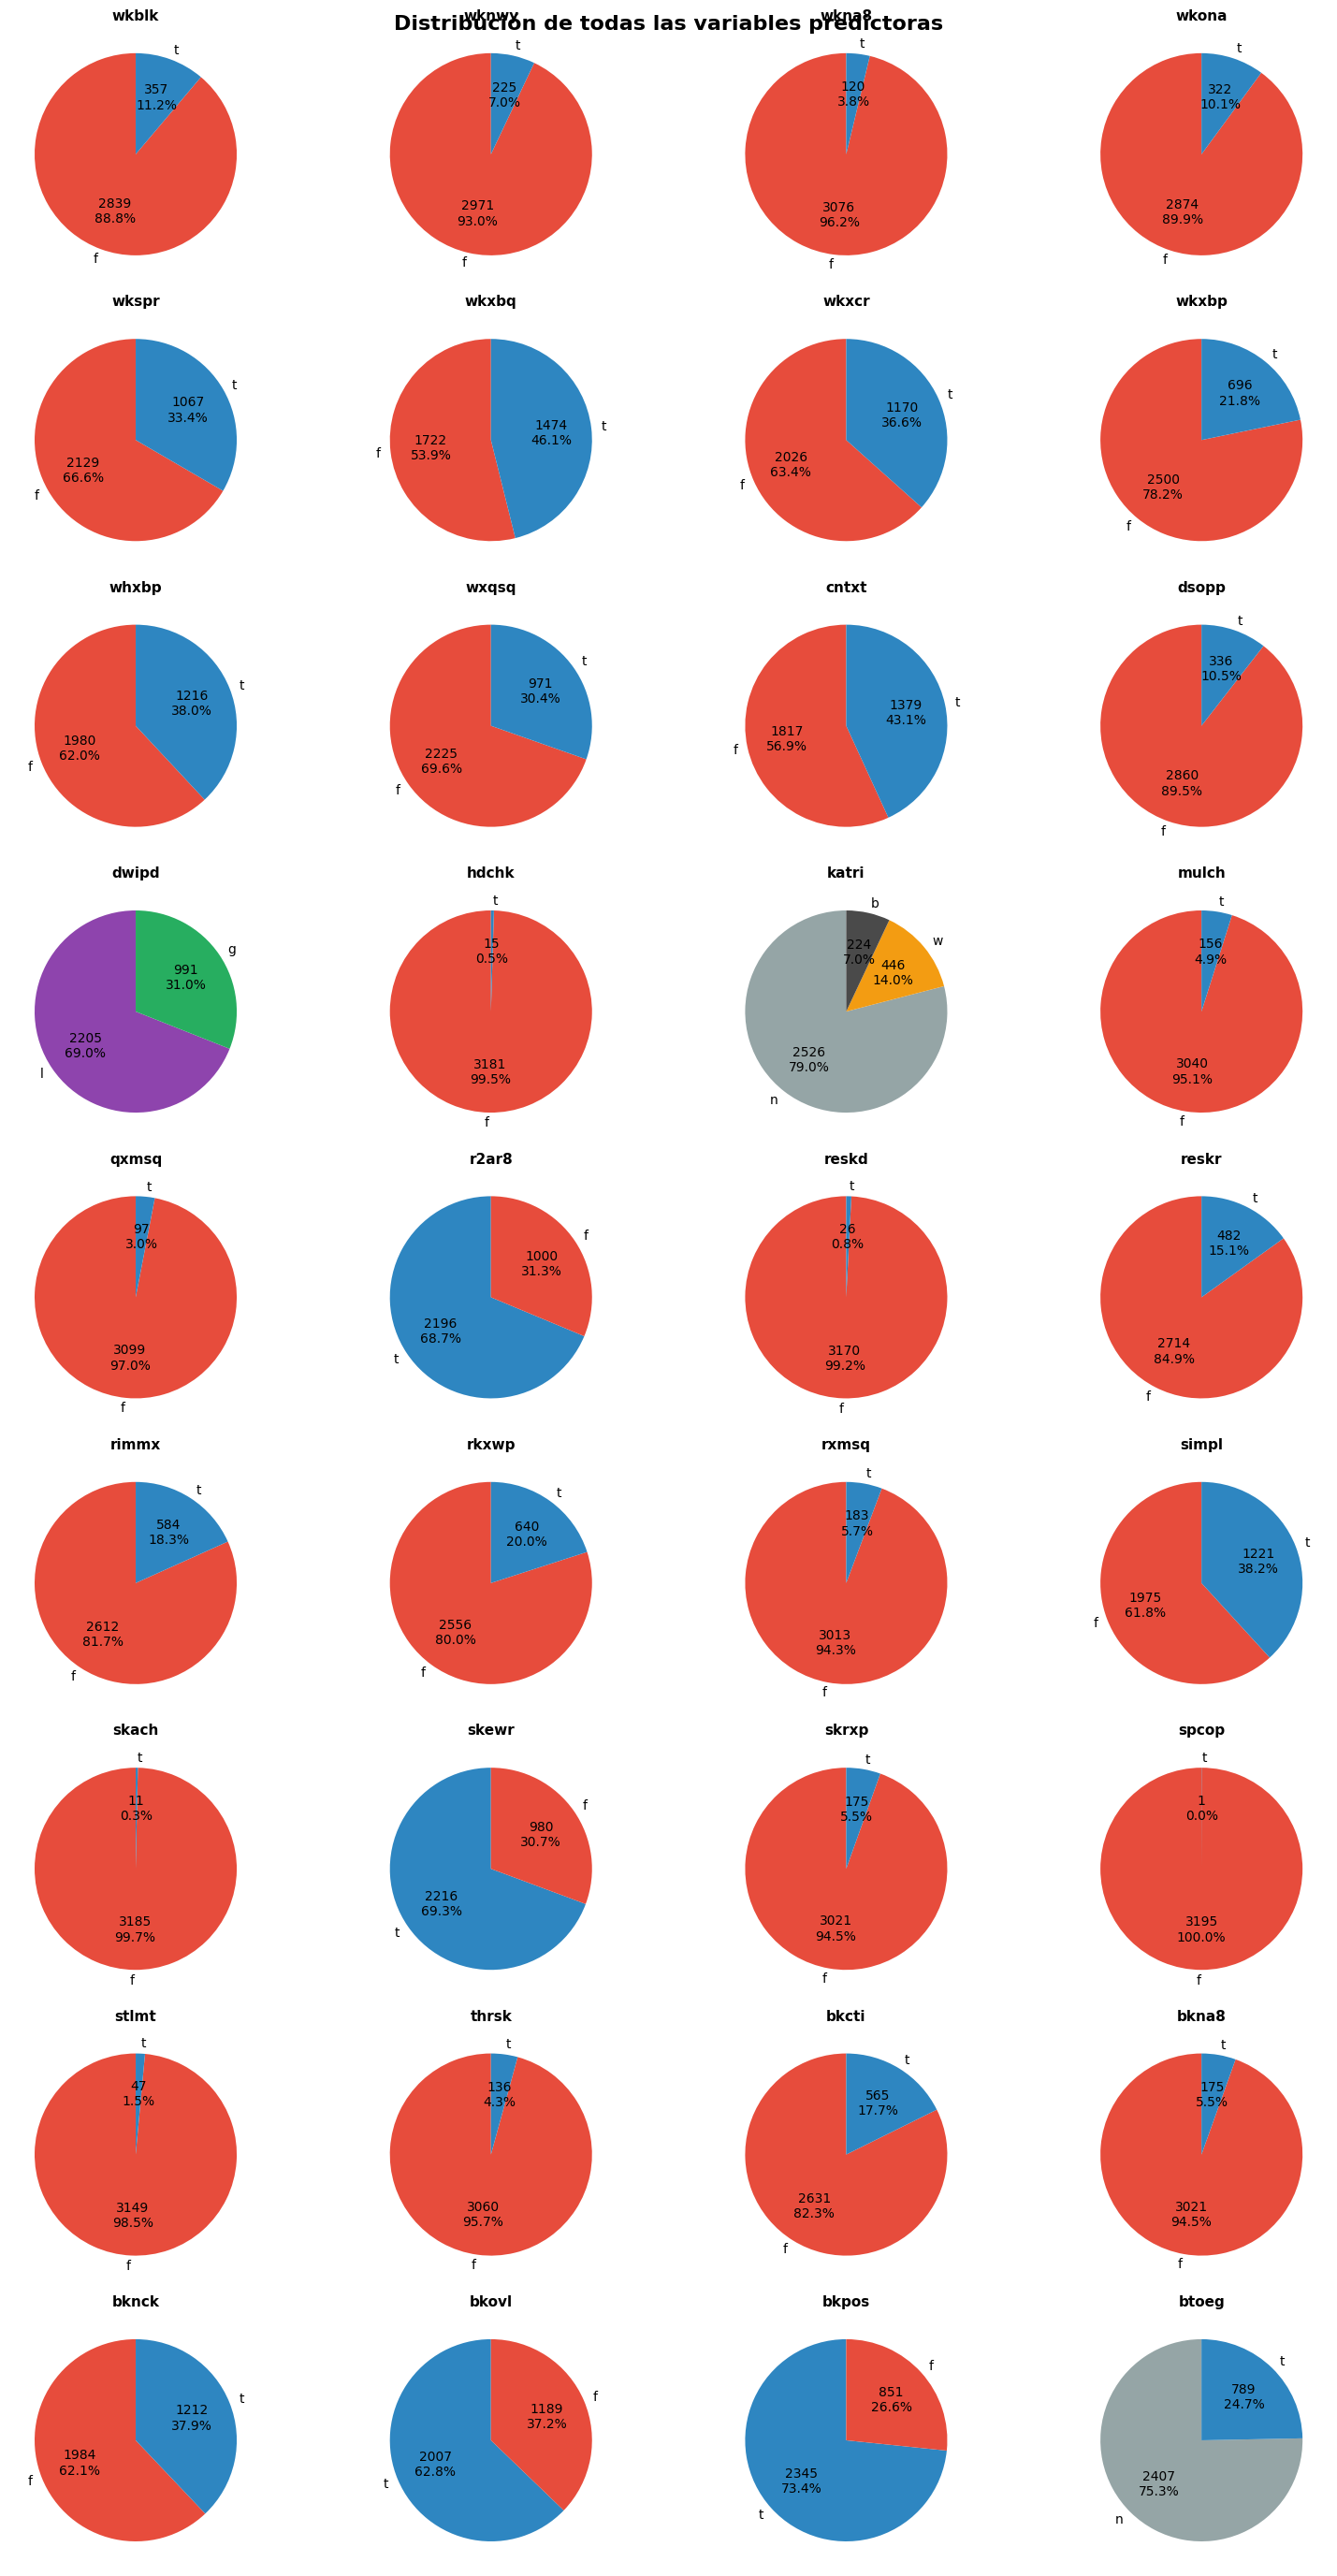

In [6]:
colores_personalizados = {
    't': '#2E86C1',   
    'f': '#E74C3C',
    'n': '#95A5A6',   
    'b': '#4A4A4A',   
    'w': '#F39C12',   
    'g': '#27AE60',   
    'l': '#8E44AD'    
}

def graficar_pastel(var, ax):
    tabla = datos[var].value_counts().reset_index()
    tabla.columns = ['valor', 'n']
    tabla['Porcentaje'] = round((tabla['n'] / tabla['n'].sum()) * 100, 1)
    tabla['Etiqueta'] = tabla['n'].astype(str) + "\n" + tabla['Porcentaje'].astype(str) + "%"
    
    colores_usar = [colores_personalizados.get(v, '#999999') for v in tabla['valor']]
    
    ax.pie(tabla['n'], labels=tabla['valor'], autopct=lambda pct: f'{int(round(pct/100*sum(tabla["n"]),0))}\n{pct:.1f}%',
           colors=colores_usar, startangle=90, textprops={'fontsize': 10})
    ax.set_title(var, fontsize=11, fontweight='bold')

# Crear grid de gráficos (9 filas x 4 columnas = 36 variables)
fig, axes = plt.subplots(9, 4, figsize=(16, 28))
axes = axes.flatten()

for i, var in enumerate(vars_predictoras):
    graficar_pastel(var, axes[i])

# Ocultar ejes vacíos
for j in range(len(vars_predictoras), len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribución de todas las variables predictoras', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

whxbp: La torre blanca ataca al peón negro en el 38% de las posiciones .
wxqsq: Las blancas controlan la casilla de coronación (a8) en el 30.4% de las posiciones.
cntxt: El rey negro está en el borde del tablero en el 43.1% de las posiciones, lo que lo hace más vulnerable a clavadas.
También vemos que las tácticas avanzadas son extremadamente raras (Jaque oculto (hdchk) con 0.5%, re-clavada diferida (reskd) con 0.8%, oposición especial (spcop) con 0%, y clavada tras jaques (skach) con 0.3%), sin embargo, la posibilidad de una clavada (skewer) está presente en el 30.7% de las posiciones (skewr), lo que la convierte en una amenaza real.

**Variables del rey blanco (wk...)**:
Se observa que el rey blanco rara vez bloquea a su propia torre (wkblk: 88.8% falso) o se encuentra en a8 (wkna8: 96.2% falso). Sin embargo, en un porcentaje significativo de posiciones (36.6%), el rey blanco puede atacar la casilla crítica b7 (wkxcr), lo que indica que las blancas tienen oportunidades de presión sobre el peón negro.

**Variables del rey negro (bk...)**:
El rey negro está bajo presión en un porcentaje significativo de posiciones: en el 37.9% está en jaque (bknck), en el 37.2%** está sobrecargado (bkvol), y en el 26.6% está en posición de posible clavada (bkpos).

## Análisis bivariado class vs independientes

Top 10 variables más asociadas con class:
bkpos    0.145834
mulch    0.156883
wkxcr    0.163178
r2ar8    0.163851
bkna8    0.195180
katri    0.219707
wkxbp    0.232149
bknck    0.364620
wxqsq    0.379420
rimmx    0.451473
Name: class, dtype: float64


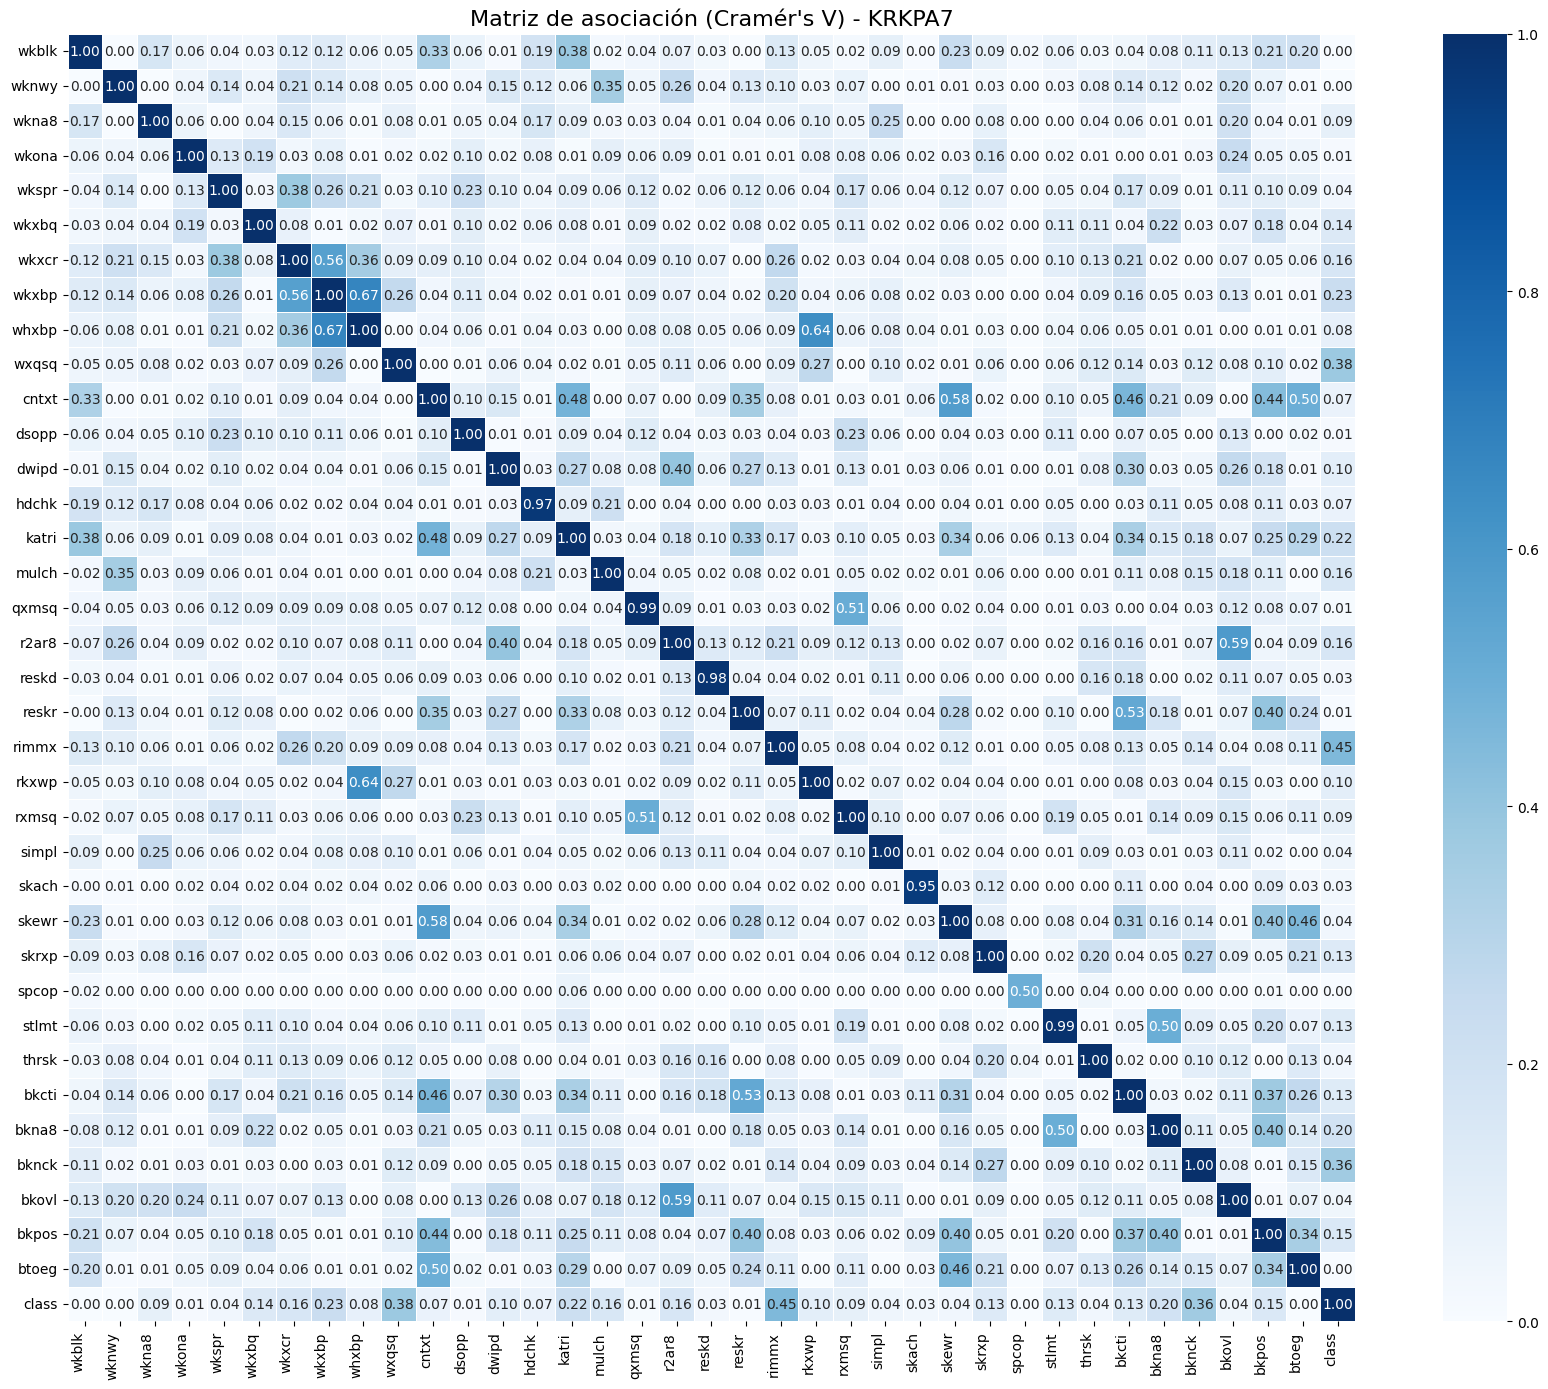

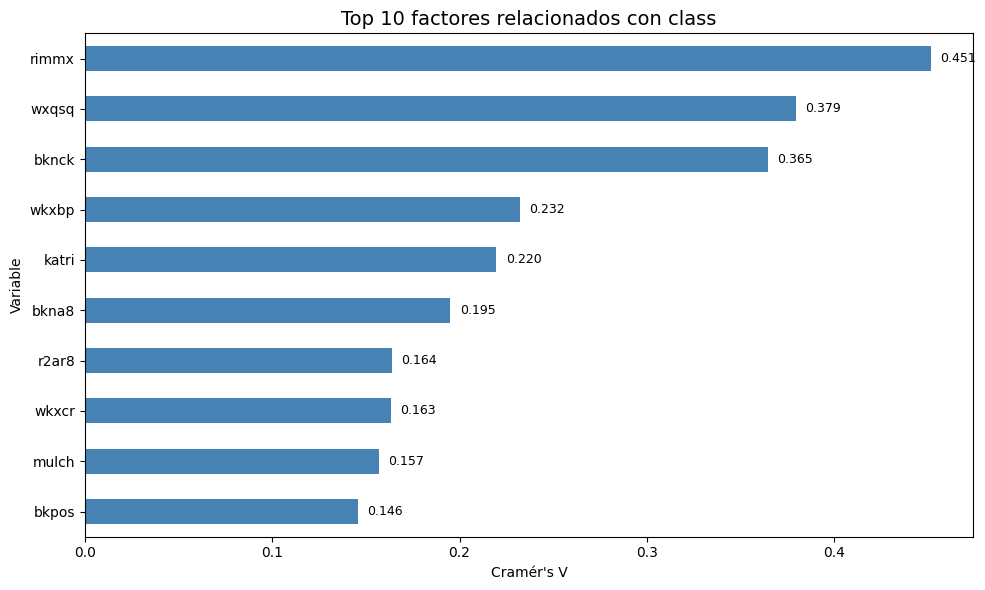

In [7]:
# Función Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, c = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, c) - 1)))

# Calcular matriz de Cramér's V
vars_todas = datos.columns.tolist()
n_vars = len(vars_todas)
cramer_matrix = np.zeros((n_vars, n_vars))

for i, var1 in enumerate(vars_todas):
    for j, var2 in enumerate(vars_todas):
        cramer_matrix[i, j] = cramers_v(datos[var1], datos[var2])

cramer_df = pd.DataFrame(cramer_matrix, index=vars_todas, columns=vars_todas)

# Extraer asociación con class
asociacion_class = cramer_df.loc['class'].drop('class').sort_values(ascending=True)  # <--- ORDEN ASCENDENTE para que el mayor quede arriba

print("Top 10 variables más asociadas con class:")
print(asociacion_class.tail(10)) 

# Heatmap de Cramér's V
plt.figure(figsize=(18, 14))
sns.heatmap(cramer_df, annot=True, fmt='.2f', cmap='Blues', square=True, 
            linewidths=0.5, annot_kws={'size': 10})
plt.title('Matriz de asociación (Cramér\'s V) - KRKPA7', fontsize=16)
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Gráfico de barras top 10 
plt.figure(figsize=(10, 6))
ax = asociacion_class.tail(10).plot(kind='barh', color='steelblue', legend=False) 

# Añadir etiquetas de valor al lado de cada barra
for i, v in enumerate(asociacion_class.tail(10)):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)  

plt.title('Top 10 factores relacionados con class', fontsize=14)
plt.xlabel('Cramér\'s V')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

# Agregar frecuencia de cada variable
frecuencia_vars = datos[vars_predictoras].count()

# Crear DataFrame con Cramér's V y frecuencia
top_vars = asociacion_class.tail(10).reset_index()
top_vars.columns = ['variable', 'cramer']
top_vars['frecuencia'] = top_vars['variable'].map(frecuencia_vars)

El heatmap muestra la fuerza de la asociación entre las variables predictoras y la variable objetivo (`class`). 
Los valores más altos (azul oscuro) indican una relación más fuerte con el resultado del final de ajedrez. Los valores más bajos (blanco) sugieren que la variable es prácticamente independiente de si la posición es ganable o no.

El análisis de asociación con Cramér's V revela que las variables más relacionadas con el resultado (`won`/`nowin`) son:

`rimmx` (0.45): Captura segura de la torre blanca. Si la torre blanca puede ser capturada de forma segura por las negras, las blancas pierden su principal ventaja.
`wxqsq` (0.38): Control blanco de la casilla de coronación (a8). Si las blancas controlan a8, evitan que el peón negro corone.
`bknck` (0.365): Rey negro en jaque. Si el rey negro está en jaque, las blancas están haciendo una amenaza directa que puede llevar a la victoria.
`wkxbp` (0.233): Rey blanco captura el peón negro. Si el rey blanco puede capturar el peón, las blancas ganan de inmediato.
`katri` (0.22): Control del punto de intersección. Si el rey blanco controla el punto de intersección, puede evitar que su propia torre sea clavada.

Ahora miremos las cuentas de `won` y `nowin` para cada variable en una tabla de contingencia: 

In [8]:

pd.set_option('display.max_rows', None)  

tabla_contingencia_list = []
for var in vars_predictoras:
    for class_val in datos['class'].unique():
        for cat in datos[var].unique():
            n = ((datos['class'] == class_val) & (datos[var] == cat)).sum()
            if n > 0:
                total_class = (datos['class'] == class_val).sum()
                pct = round((n / total_class) * 100, 1)
                tabla_contingencia_list.append({
                    'Class': class_val,
                    'Variable': var,
                    'Categoria': cat,
                    'Frecuencia': n,
                    'Porcentaje': pct
                })

tabla_contingencia = pd.DataFrame(tabla_contingencia_list)
print(tabla_contingencia)  # <--- Ahora se ven todas las filas

# Restaurar configuración por defecto (opcional)
pd.set_option('display.max_rows', 10)

     Class Variable Categoria  Frecuencia  Porcentaje
0      won    wkblk         f        1482        88.8
1      won    wkblk         t         187        11.2
2    nowin    wkblk         f        1357        88.9
3    nowin    wkblk         t         170        11.1
4      won    wknwy         f        1550        92.9
5      won    wknwy         t         119         7.1
6    nowin    wknwy         f        1421        93.1
7    nowin    wknwy         t         106         6.9
8      won    wkna8         f        1634        97.9
9      won    wkna8         t          35         2.1
10   nowin    wkna8         f        1442        94.4
11   nowin    wkna8         t          85         5.6
12     won    wkona         f        1507        90.3
13     won    wkona         t         162         9.7
14   nowin    wkona         f        1367        89.5
15   nowin    wkona         t         160        10.5
16     won    wkspr         f        1141        68.4
17     won    wkspr         

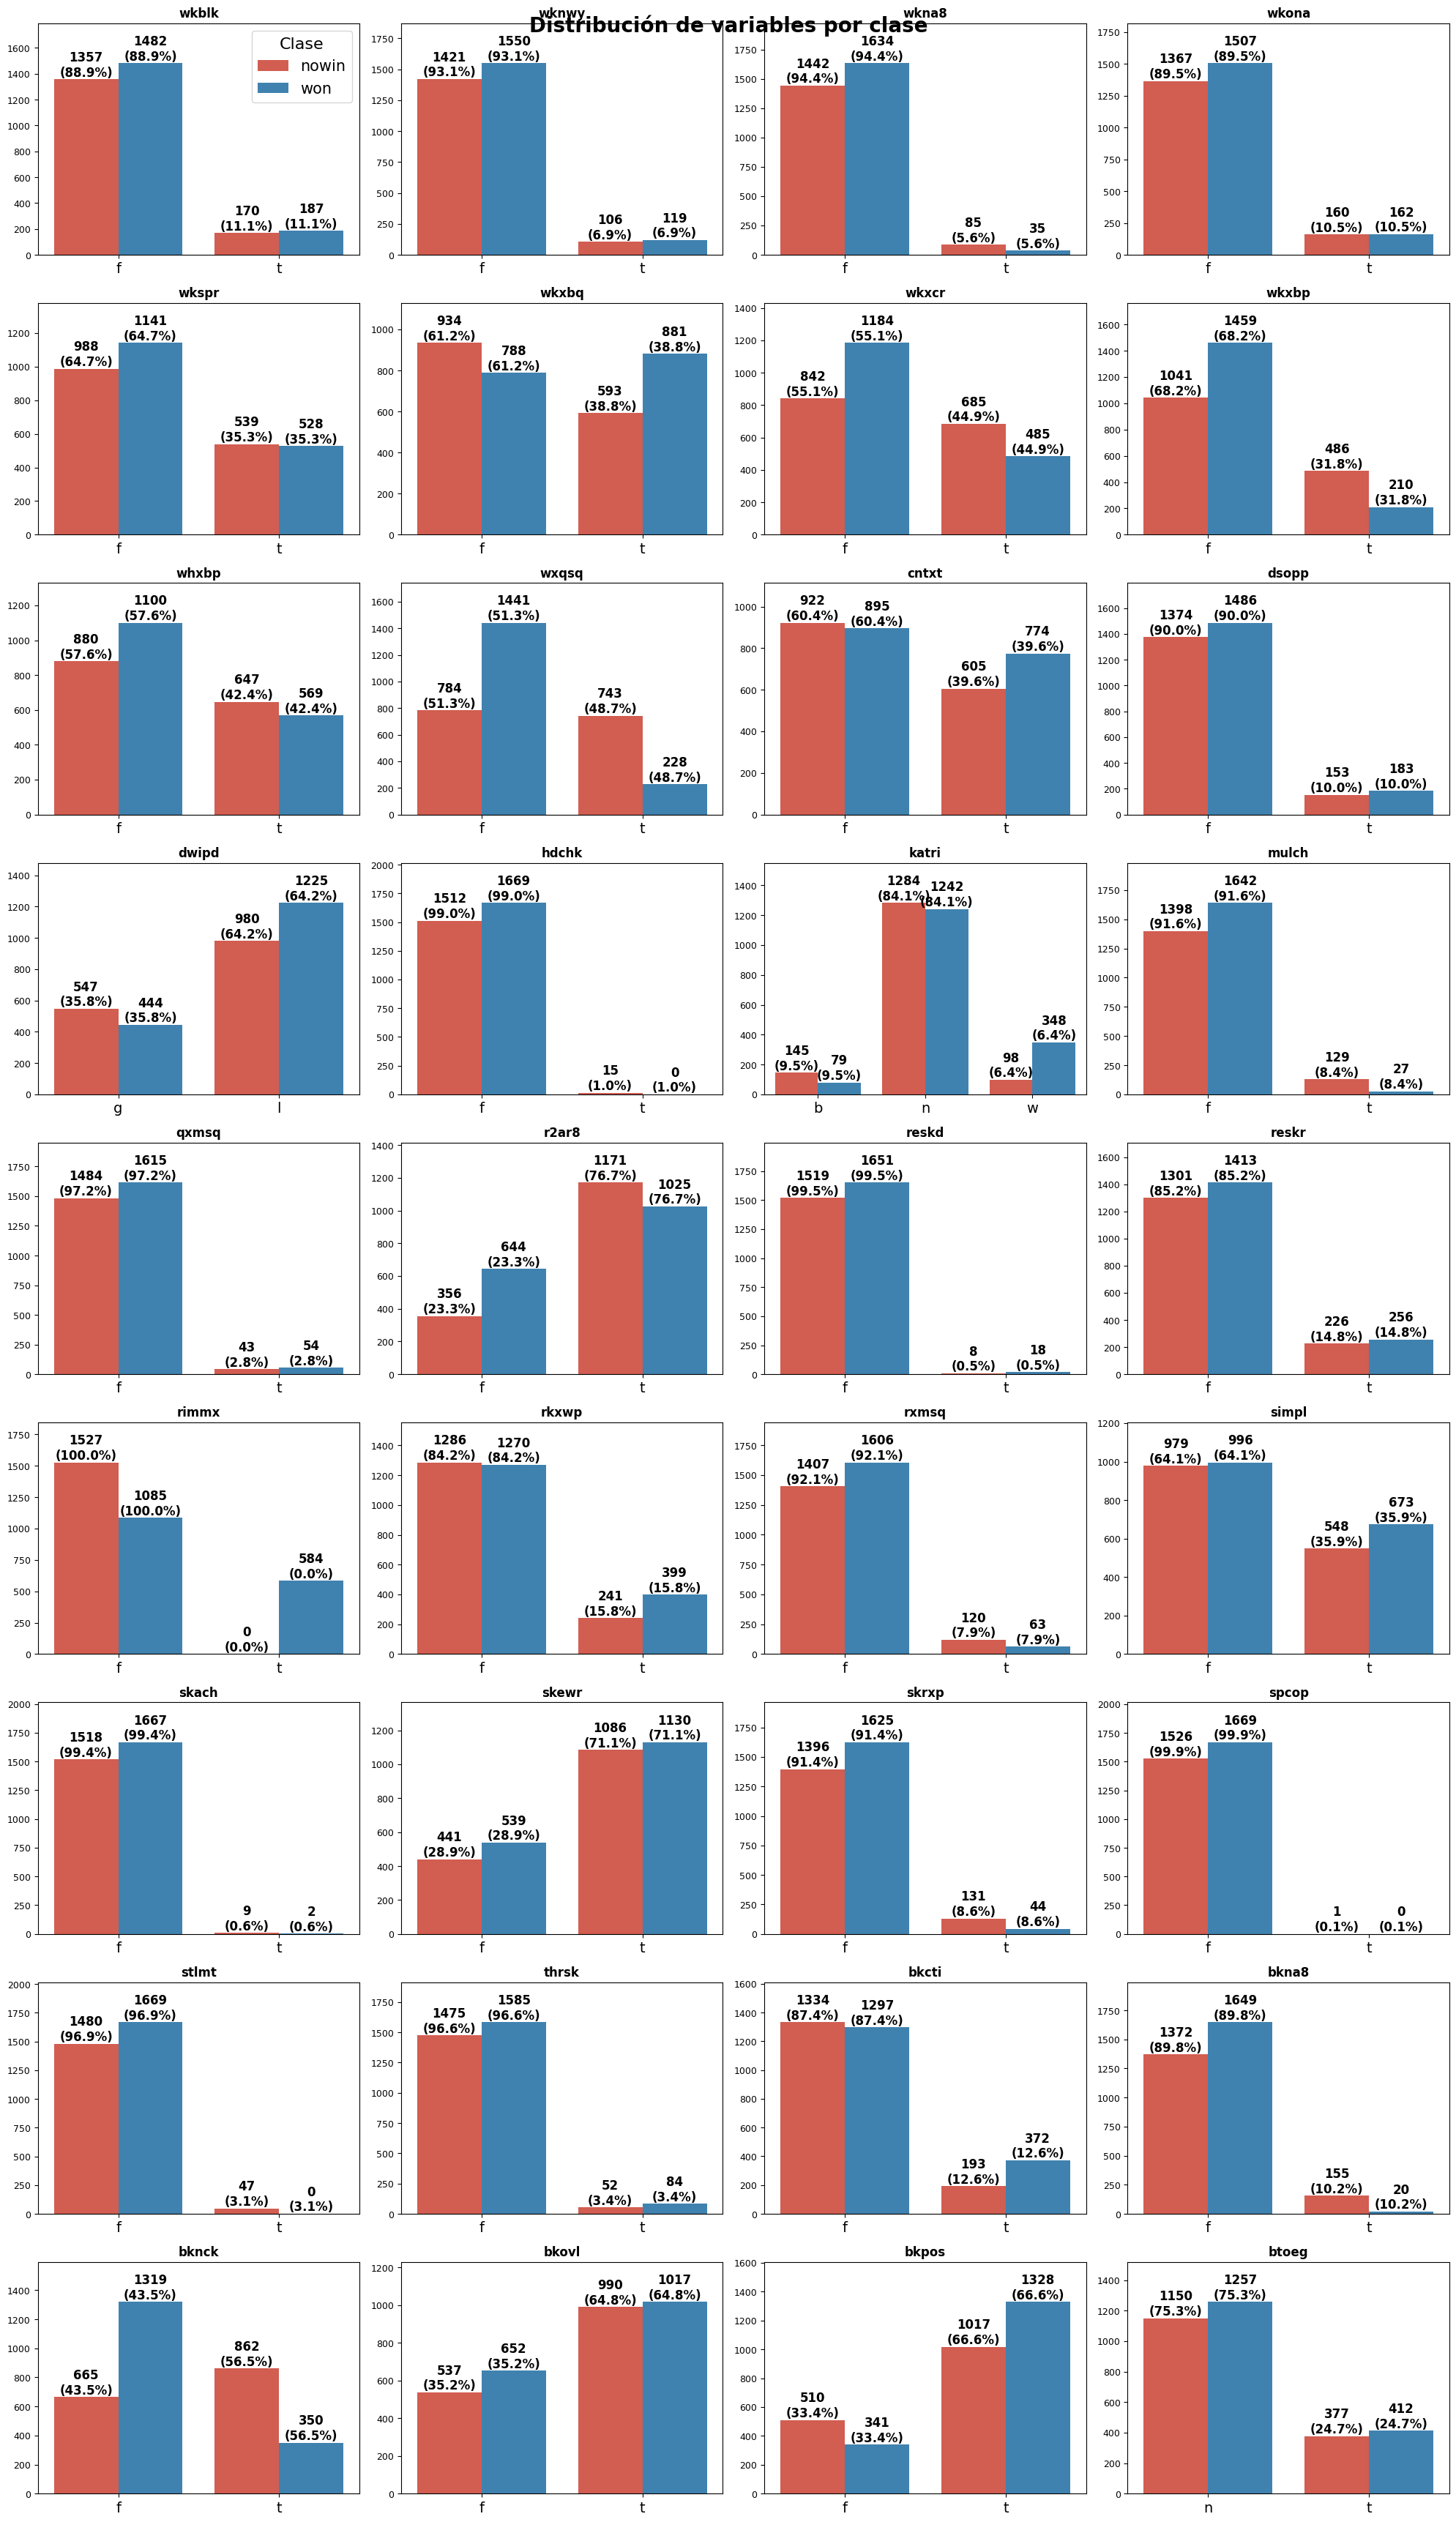

In [9]:
def graficar_barras_agrupadas(var, ax, mostrar_leyenda=False):
    df_plot = datos.groupby(['class', var]).size().reset_index(name='n')
    df_plot['porcentaje'] = df_plot.groupby('class')['n'].transform(lambda x: round(x / x.sum() * 100, 1))
    
    # Gráfico de barras
    sns.barplot(data=df_plot, x=var, y='n', hue='class', ax=ax, palette=['#E74C3C', '#2E86C1'])
    
    # Añadir etiquetas de n y porcentaje sobre cada barra 
    for container in ax.containers:
        if container is not None and len(container) > 0:
            try:
                n_values = [bar.get_height() for bar in container]
                p_values = df_plot['porcentaje'].iloc[:len(n_values)]
                labels = [f'{int(h)}\n({p}%)' for h, p in zip(n_values, p_values)]
                ax.bar_label(container, labels=labels, fontsize=12, fontweight='bold')  
            except:
                pass
    
    # Configurar gráfico
    ax.set_title(var, fontsize=12, fontweight='bold') 
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    y_max = ax.get_ylim()[1]
    ax.set_ylim(0, y_max * 1.15)

    # Leyenda 
    if mostrar_leyenda:
        ax.legend(loc='upper right', title='Clase', fontsize=15, title_fontsize=16) 
    else:
        ax.legend().remove()
    
    ax.tick_params(axis='x', rotation=0, labelsize=14)  # <--- AUMENTADO
    ax.tick_params(axis='y', labelsize=9)  # <--- AUMENTADO


# Crear grid de gráficos (figura más grande)
fig, axes = plt.subplots(9, 4, figsize=(20, 35))  
axes = axes.flatten()

# Graficar todas las variables (solo la primera con leyenda)
for i, var in enumerate(vars_predictoras):
    mostrar_leyenda = (i == 0)
    graficar_barras_agrupadas(var, axes[i], mostrar_leyenda)

for j in range(len(vars_predictoras), len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribución de variables por clase', fontsize=20, fontweight='bold')  
plt.tight_layout()
plt.show()

**Factores asociados con la victoria (`won`)**:

`katri` (w): Cuando el rey blanco controla el punto de intersección (`katri = w`), la proporción de `won` (20.9%) es más del triple que en `nowin` (6.4%). Controlar el punto de intersección impide que la torre blanca sea clavada.

`rkxwp` (t): Cuando la torre blanca amenaza al peón negro (`rkxwp = t`), el 23.9% de los casos son `won` y el 15.8% son `nowin`. La amenaza de la torre sobre el peón favorece a las blancas, pero no es un factor determinante por sí solo.

`bkpos` (t): Cuando el rey negro está en posición de posible clavada (`bkpos = t`), es ligeramente más común en `won` (79.6%) que en `nowin` (66.6%). Sin embargo, la diferencia no es muy grande, lo que indica que no es un factor determinante por sí solo. La posición del rey negro en posible clavada puede favorecer a las blancas, pero otros factores son más importantes.

**Factores asociados con la no victoria (`nowin`)**:

`rimmx` (f): Cuando la torre blanca no puede ser capturada de forma segura por el rey negro (`rimmx = f`), se da el 100% de los casos de `nowin`. Esto significa que, si la torre está segura pero no puede atacar el peón, este corona sin oposición. Esta es la relación más fuerte.

`bkna8` (t): Cuando el rey negro está en a8 (`bkna8 = t`), es 5 veces más frecuente en `nowin` (10.2%) que en `won` (1.2%). Esto indica que la presencia del rey negro en a8 es un predictor fuerte de `nowin`, ya que el rey negro defiende la casilla de coronación y protege el peón.

`bknck` (t): Cuando el rey negro está en jaque (`bknck = t`), es 2.7 veces más frecuente en `nowin` (56.5%) que en `won` (21.0%). Esto indica que el jaque al rey negro no siempre es favorable para las blancas.

`wkxbp` (t): Cuando el rey blanco puede capturar el peón (`wkxbp = t`), es 2.5 veces más frecuente en `nowin` (31.8%) que en `won` (12.6%). Esto es contra intuitivo, ya que se esperaría que capturar el peón llevara a la victoria, pero los datos muestran lo contrario.

`wxqsq` (t): Cuando las blancas controlan la casilla de coronación a8 (`wxqsq = t`), es 3.5 veces más frecuente en `nowin` (48.7%) que en `won` (13.7%). Esto es contra intuitivo también.

**Variables con poca diferencia**:

Las variables `wkblk`, `wknwy`, `dsopp`, `qxmsq`, `reskd`, `reskr` y `btoeg` presentan distribuciones muy  entre `won` y `nowin`, lo que indica que podrían no ser útiles para predecir el resultado.

## Relaciones entre variables predictoras

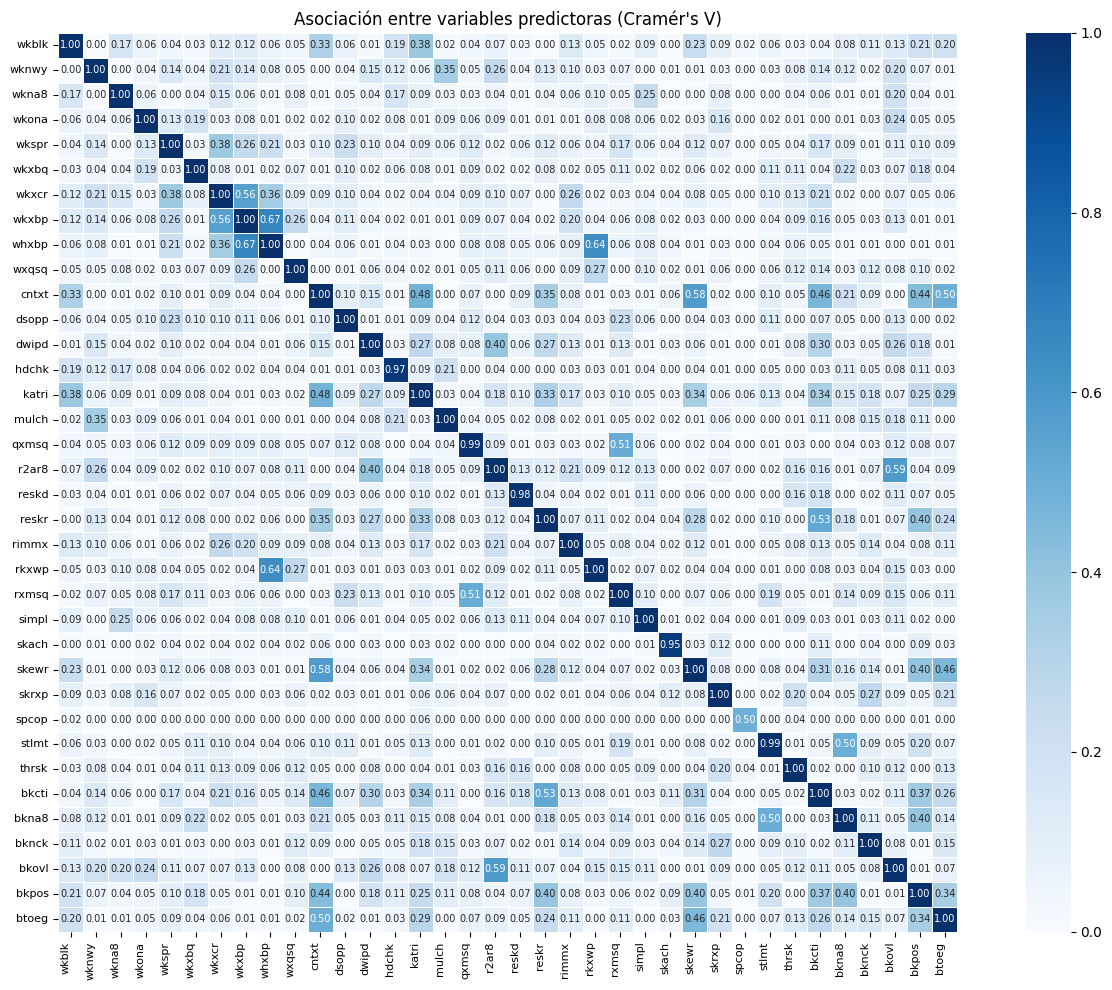

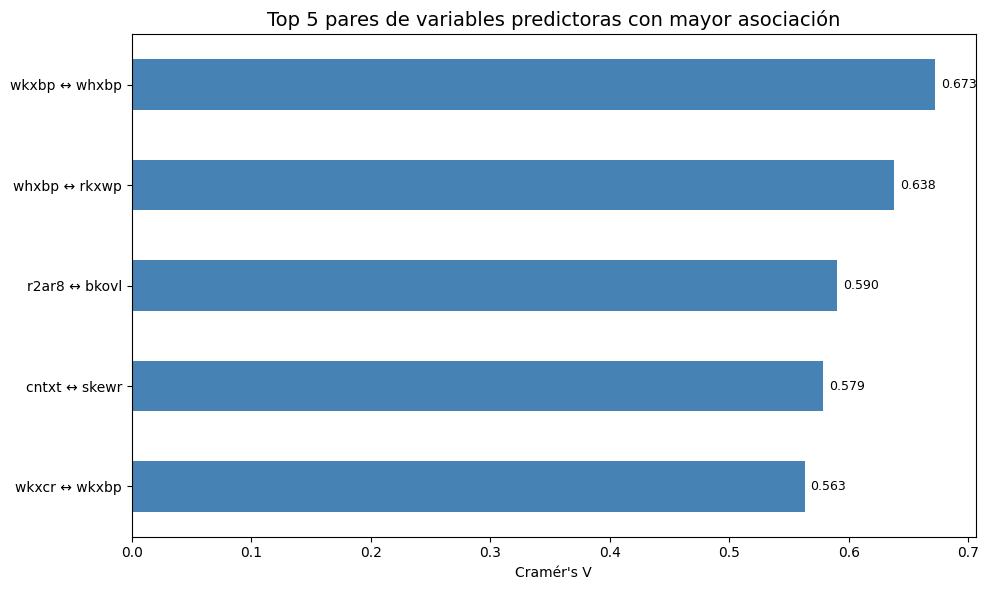

In [10]:
# Calcular Cramér's V solo entre predictoras
vars_pred = [col for col in datos.columns if col != 'class']
n_pred = len(vars_pred)
cramer_pred = np.zeros((n_pred, n_pred))

for i, var1 in enumerate(vars_pred):
    for j, var2 in enumerate(vars_pred):
        cramer_pred[i, j] = cramers_v(datos[var1], datos[var2])

cramer_pred_df = pd.DataFrame(cramer_pred, index=vars_pred, columns=vars_pred)

# Heatmap de predictoras (TAMAÑO CORREGIDO)
plt.figure(figsize=(14, 10))  # <--- REDUCIDO
sns.heatmap(cramer_pred_df, annot=True, fmt='.2f', cmap='Blues', square=True,
            linewidths=0.5, annot_kws={'size': 7})  # <--- TEXTO MÁS PEQUEÑO
plt.title('Asociación entre variables predictoras (Cramér\'s V)', fontsize=12)
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Top 5 pares de predictoras
pares_list = []
for i in range(n_pred):
    for j in range(i+1, n_pred):
        pares_list.append({'var1': vars_pred[i], 'var2': vars_pred[j], 'cramer': cramer_pred[i, j]})

pares_df = pd.DataFrame(pares_list)

# Ordenar descendente y tomar los 5 mayores
top5_pares = pares_df.sort_values('cramer', ascending=False).head(5)

# Crear etiqueta con el par de variables
top5_pares['par'] = top5_pares['var1'] + ' ↔ ' + top5_pares['var2']

# Gráfico de barras horizontal
plt.figure(figsize=(10, 6))
ax = top5_pares.set_index('par')['cramer'].plot(kind='barh', color='steelblue', legend=False)
ax.invert_yaxis()  

# Añadir etiquetas de valor al lado de cada barra
for i, v in enumerate(top5_pares['cramer']):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

plt.title('Top 5 pares de variables predictoras con mayor asociación', fontsize=14)
plt.xlabel('Cramér\'s V')
plt.ylabel('')
plt.tight_layout()
plt.show()

Para evaluar si existen variables redundantes (que miden información similar), se calculó la matriz de Cramer's V excluyendo la variable objetivo `class`. Los valores más altos indican que dos variables están asociadas entre sí, lo que sugiere que podrían estar midiendo conceptos relacionados:

`whxbp` ↔ `wkxbp` (0.67) Captura del peón negro por la torre blanca vs captura por el rey blanco. Ambas miden si el peón puede ser capturado, lo que sugiere que están altamente relacionadas.

`rkxwp` ↔ `whxbp` (0.639) Amenaza de la torre blanca sobre el peón vs ataque de la torre blanca al peón. Miden conceptos similares, ambos de la torre blanca sobre el peón negro. 

`bkovl` ↔ `r2ar8` (0.591) Rey negro sobrecargado vs acceso de la torre blanca a la columna A o fila 8. Si la torre blanca tiene acceso, el rey negro se sobrecarga al tener que defender múltiples amenazas. 

`cntxt` ↔ `skewr` (0.579) Rey negro en el borde (no a8) vs posibilidad de clavada. Si el rey negro está en el borde, es más vulnerable a una clavada de la torre blanca.

`wkxbp` ↔ `wkxcr` (0.564) Rey blanco captura el peón vs rey blanco ataca b7. Ambas miden la capacidad del rey blanco para presionar al peón negro. 


Ninguno de estos valores superan el 0.7, lo que indica que no hay variables altamente redundantes, es decir, que presenten multicolinealidad muy alta. Sin embargo, las relaciones moderadas (0.5 - 0.67) sugieren que algunos pares de variables miden conceptos relacionados desde diferentes perspectivas.


## Conclusiones

El análisis exploratorio permitió identificar los principales factores que determinan el resultado 
del final de ajedrez Rey+Torre (blancas) vs Rey+Peón (negras) en a7.

1. La variable objetivo 'class' presenta una distribución prácticamente balanceada (52.2% won, 47.8% nowin).

2. La mayoría de las variables predictoras son binarias (t/f), con excepción de dwipd (g/l) y katri (única ternaria: n/b/w).

3. Tácticas avanzadas como el jaque oculto (hdchk, 0.5%), la re-clavada diferida (reskd, 0.8%), 
   la clavada tras jaques (skach, 0.3%) y la oposición especial (spcop, 0%) son muy raras.

4. La variable más determinante es rimmx (Cramér's V = 0.45): cuando la torre blanca no puede ser capturada 
   de forma segura (rimmx = f), se da el 100% de los casos de nowin.

5. Otras variables con alta asociación: wxqsq (0.38) y bknck (0.365).

6. No hay variables altamente redundantes (ninguna supera 0.7 de Cramér's V).

7. El resultado del final depende de la combinación de múltiples factores, destacando:
   - Seguridad de la torre (rimmx)
   - Control del punto de intersección (katri)
   - Posición del rey negro (bkna8, bknck)